In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.tree import plot_tree
from sklearn.linear_model import LogisticRegression

In [ ]:
# Cargar y limpiar la data
data = pd.read_csv("data_train_cleaned_partition_matlab_all_cols.csv")
data["Delay_from_due_date"] = np.where(data["Delay_from_due_date"] < 0, 0, data["Delay_from_due_date"])
data["Credit_Score_Score"] = np.where(data["Credit_Score"] == "Poor", 1,
                                      np.where(data["Credit_Score"] == "Standard", 2, 3))

cols_remove = ['Idx','Index','ID', 'Customer_ID','Month','Name','SSN', 'Occupation'] 
data = data.drop(cols_remove, axis=1)                            

In [7]:
# Función para dividir en data de entrenamiento y prueba
def create_data(data, col_feature:str):
    X = data[col_feature].values.reshape(-1, 1)
    y = data["Credit_Score"].astype('category').cat.codes.values

    X_clase_0 = X[y == 0][:10000]
    y_clase_0 = y[y == 0][:10000]
    X_clase_1 = X[y == 1][:10000]
    y_clase_1 = y[y == 1][:10000]
    X_clase_2 = X[y == 2][:10000]
    y_clase_2 = y[y == 2][:10000]

    X = np.concatenate([X_clase_0, X_clase_1, X_clase_2])
    y = np.concatenate([y_clase_0, y_clase_1, y_clase_2])
    return X, y
# Modelo simple de un solo árbol de decisión
def create_decission_tree(data, col_feature:str, depth=2):
    data_model = data.copy()

    # Crear el árbol de decisión con profundidad máxima de 3
    modelo = DecisionTreeClassifier(max_depth=depth)
    X, y = create_data(data_model, col_feature)

    modelo.fit(X,y)

    predicciones_train = modelo.predict(X)
    accuracy = accuracy_score(y, predicciones_train)
    print(f'Accuracy en datos de entrenamiento: {accuracy:.2f}')

    plt.figure(figsize=(8, 6))
    plot_tree(modelo, filled=True, feature_names=[col_feature], class_names=["Good", "Poor", "Standard"])
    plt.show()
# Modelo de regresión logística
def create_logistic_regression(data, col_feature:str):
    data_model = data.copy()

    # Crear el árbol de decisión con profundidad máxima de 3
    modelo = LogisticRegression()
    X, y = create_data(data_model, col_feature)

    modelo.fit(X,y)

    predicciones_train = modelo.predict(X)
    accuracy = accuracy_score(y, predicciones_train)
    print(f'Accuracy en datos de entrenamiento: {accuracy:.2f}')
    print(modelo.coef_)
    print(modelo.intercept_)
# Crear histogramas apilados por categoría de n bins
def create_histogram(data, column, bins=3, title=None):
    # Definir categorías
    categories = data['Credit_Score'].unique()
    # Crear listas separadas por categoría
    hist_data = [data.loc[data['Credit_Score'] == cat, column] for cat in categories]
    # Graficar histograma apilado
    plt.hist(hist_data, bins=bins, stacked=True, label=categories, alpha=0.7, edgecolor="black")
    plt.legend(title='Credit Score')
    plt.title(f'{column} by Credit Score')

    if type(data[column].iloc[0]) == str:
        data[column] = data[column].astype('category').cat.codes
    corr = data[column].corr(data['Credit_Score_Score'])
    print(corr)

In [ ]:
# Porcentaje de los grupos
data.groupby("Credit_Score")["Monthly_Inhand_Salary"].count()/data.shape[0]

Credit_Score
Good        0.178117
Poor        0.288277
Standard    0.533606
Name: Monthly_Inhand_Salary, dtype: float64

In [6]:
# Proporción de los grupos para el ajuste de Outstanding_Debt
mask = (data['Payment_of_Min_Amount']=="Yes")&(data['Outstanding_Debt']>2000)
data[mask].groupby("Credit_Score")["Monthly_Inhand_Salary"].count()/data[mask].shape[0]

Credit_Score
Good        0.017347
Poor        0.572731
Standard    0.409923
Name: Monthly_Inhand_Salary, dtype: float64

-0.3107418803392111


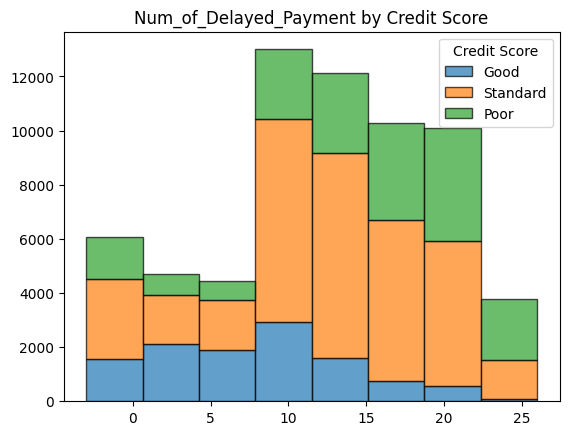

In [ ]:
# A continuación se analiza variable por variable, y algunos ajustes (condicionales) que se pretenden realizar
create_histogram(data, 'Num_of_Delayed_Payment', bins=8)

Accuracy en datos de entrenamiento: 0.46


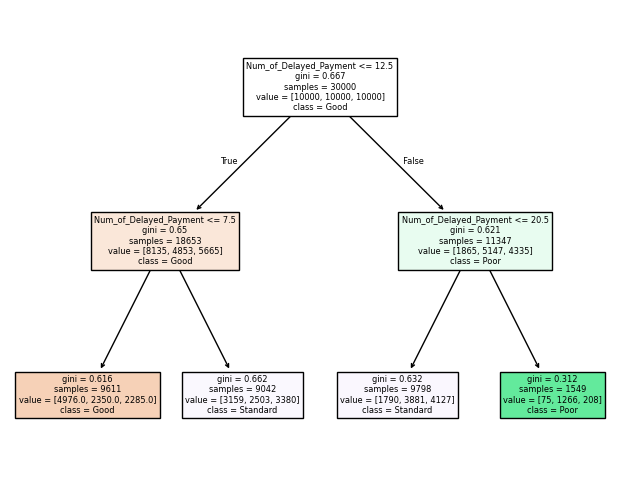

In [9]:
create_decission_tree(data, 'Num_of_Delayed_Payment', depth=2)

-0.4298802783365475


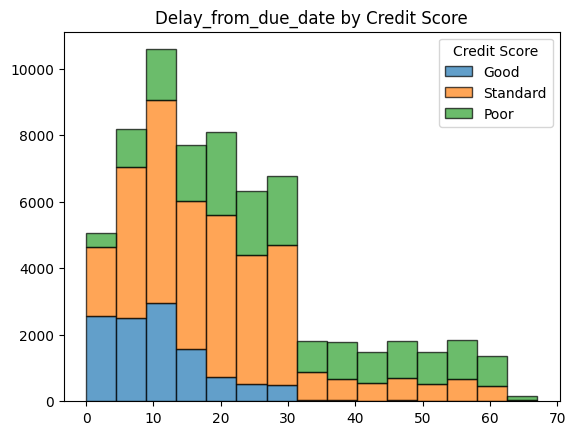

In [10]:
create_histogram(data, 'Delay_from_due_date', bins=15) # VARIABLE CHIDA

-0.19161410473896084


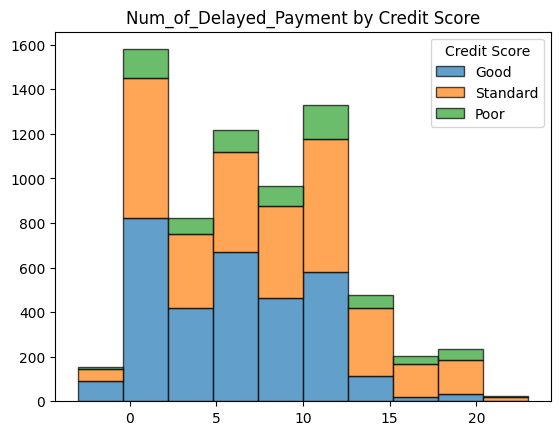

In [11]:
create_histogram(data[data["Delay_from_due_date"]<6], "Num_of_Delayed_Payment", bins=10) # VARIABLE CHIDA

-0.3852670935328399


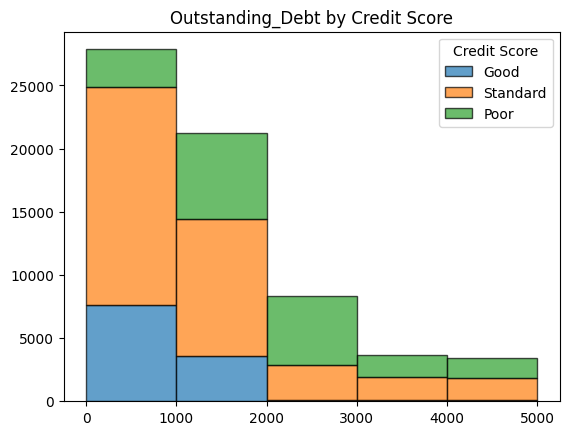

In [12]:
create_histogram(data, 'Outstanding_Debt', bins=5) # VARIABLE CHIDA

0.06403159977779187


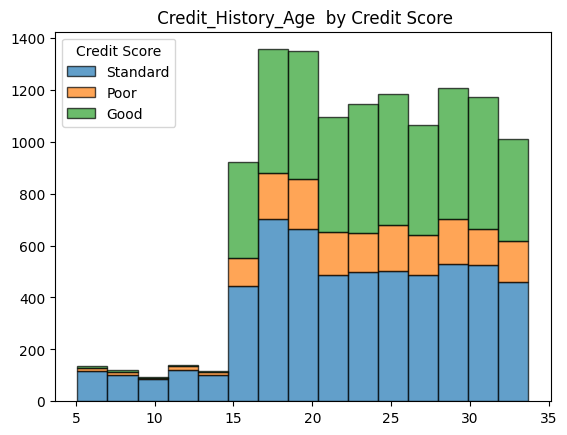

In [ ]:
# Ajuste de Credit History Age y la Tasa de Interés
condition = (data[' Credit_History_Age '] > 5) & (data['Interest_Rate'] < 7)
data_condition = data[condition].copy()

create_histogram(data_condition, ' Credit_History_Age ', bins=15) # ' Credit_History_Age '

0.3064449374005281


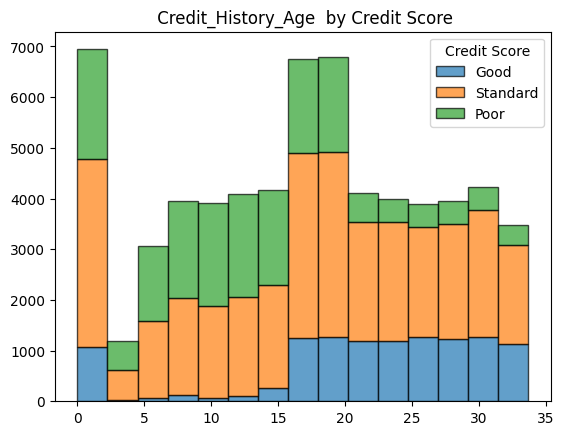

In [14]:
create_histogram(data, ' Credit_History_Age ', bins=15) 

Accuracy en datos de entrenamiento: 0.46


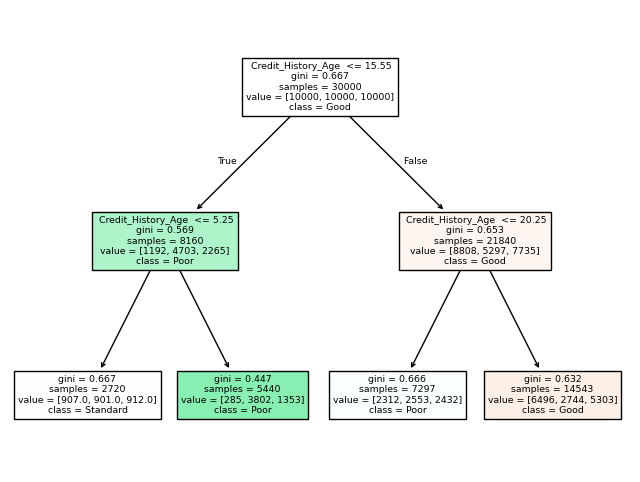

In [ ]:
# Analizar el split de CRedit History que realiza un solo árbol de decisión
create_decission_tree(data, ' Credit_History_Age ', depth=2) # ' Credit_History_Age '

In [17]:
# Ajuste de Credit History Age según la regresión logística
create_logistic_regression(data, ' Credit_History_Age ')

Accuracy en datos de entrenamiento: 0.45
[[ 0.0347336 ]
 [-0.04115779]
 [ 0.0064242 ]]
[-0.68249119  0.77004346 -0.08755227]


0.045670066141878976


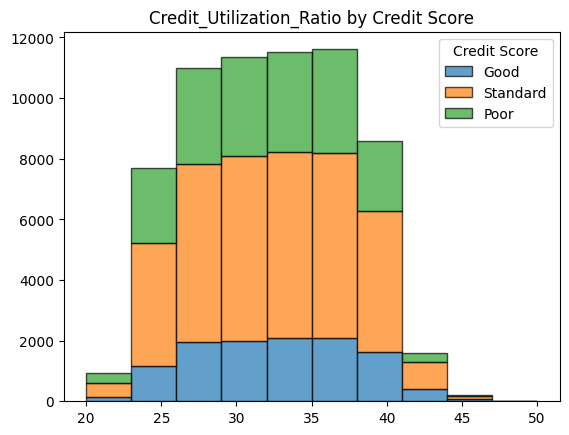

In [18]:
create_histogram(data, 'Credit_Utilization_Ratio', bins=10)

-0.3986190490798186


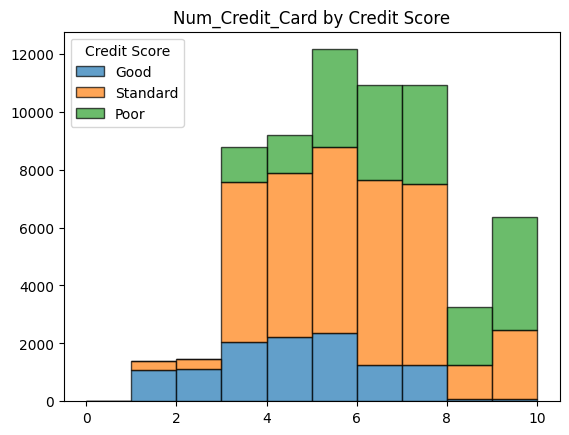

In [19]:
create_histogram(data, 'Num_Credit_Card', bins=10)

-0.39424544523898053


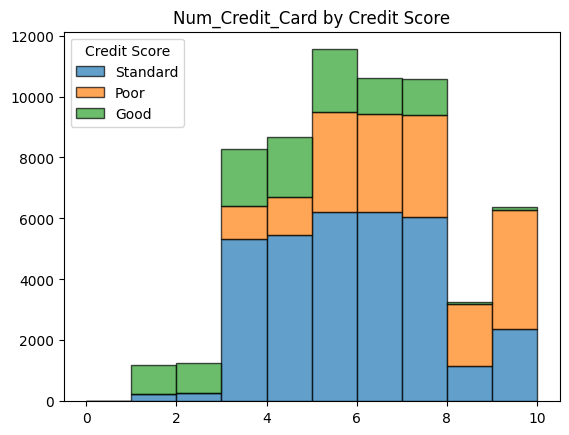

In [25]:
create_histogram(data[data['Num_Bank_Accounts']>0], 'Num_Credit_Card', bins=10)

Accuracy en datos de entrenamiento: 0.46


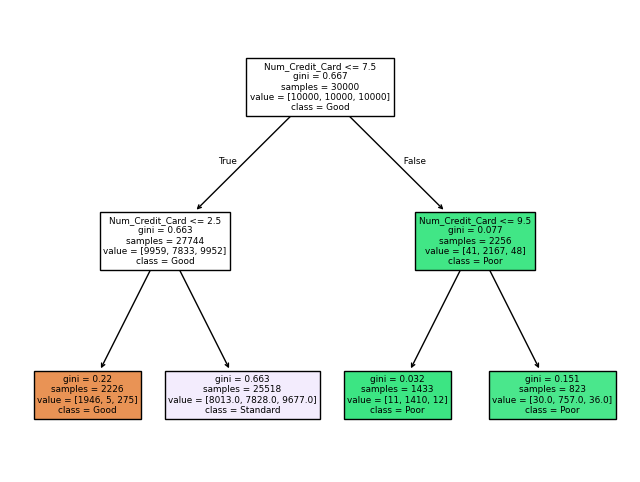

In [26]:
create_decission_tree(data, 'Num_Credit_Card', depth = 2)

In [27]:
create_logistic_regression(data, 'Num_Credit_Card')

Accuracy en datos de entrenamiento: 0.45
[[-0.29722415]
 [ 0.34117121]
 [-0.04394706]]
[ 1.45537928 -1.77946842  0.32408914]


-0.09775696392616016


C:\Users\tony_\AppData\Local\Temp\ipykernel_19892\196986832.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Payment_Behaviour'].fillna("NO_DATA", inplace=True)


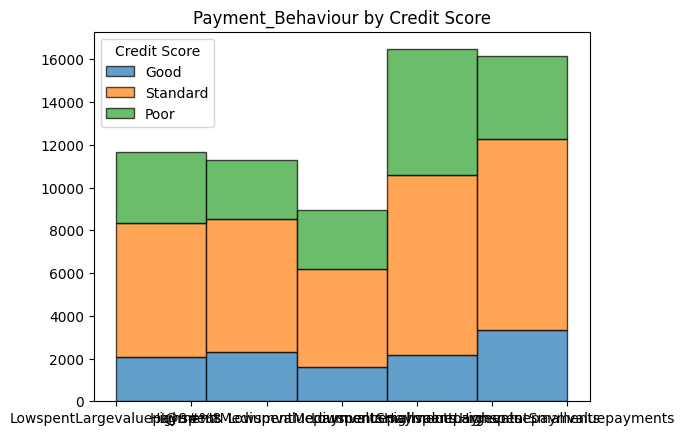

In [28]:
data['Payment_Behaviour'].fillna("NO_DATA", inplace=True)
create_histogram(data, 'Payment_Behaviour', bins=5)

-0.480163267911306


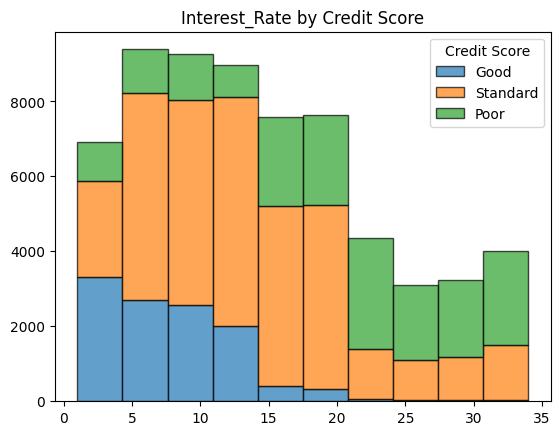

In [29]:
percentil = data['Interest_Rate'].quantile(0.99)
data['Interest_Rate'] = np.where(data['Interest_Rate'] > percentil, percentil, data['Interest_Rate'])
create_histogram(data, 'Interest_Rate', bins=10)

-0.39901669520709915


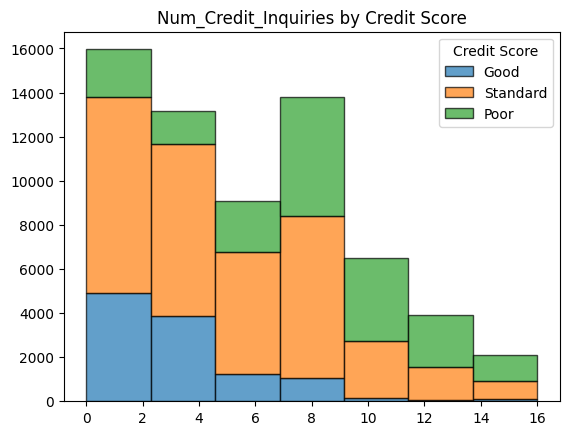

In [31]:
percentil = data['Num_Credit_Inquiries'].quantile(0.99)
data['Num_Credit_Inquiries'] = np.where(data['Num_Credit_Inquiries'] > percentil, percentil, data['Num_Credit_Inquiries'])

create_histogram(data, 'Num_Credit_Inquiries', bins=7)

Accuracy en datos de entrenamiento: 0.48


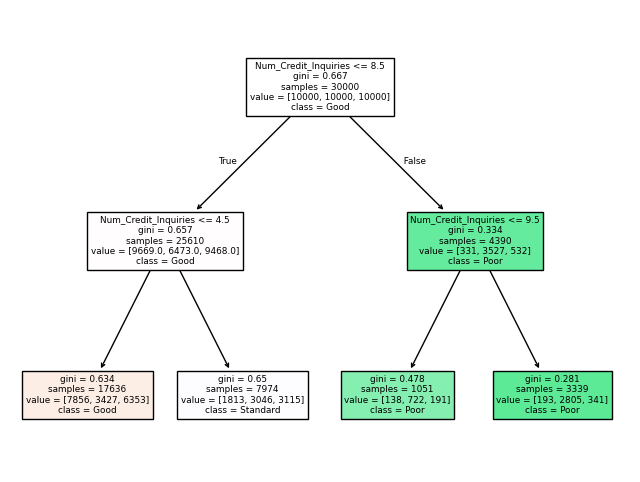

In [32]:
create_decission_tree(data, 'Num_Credit_Inquiries', depth = 2)

In [23]:
create_logistic_regression(data, 'Num_Credit_Inquiries')

Accuracy en datos de entrenamiento: 0.49
[[-0.13597788]
 [ 0.17877245]
 [-0.04279457]]
[ 0.6047513  -0.87994551  0.27519421]


-0.32509372191348385


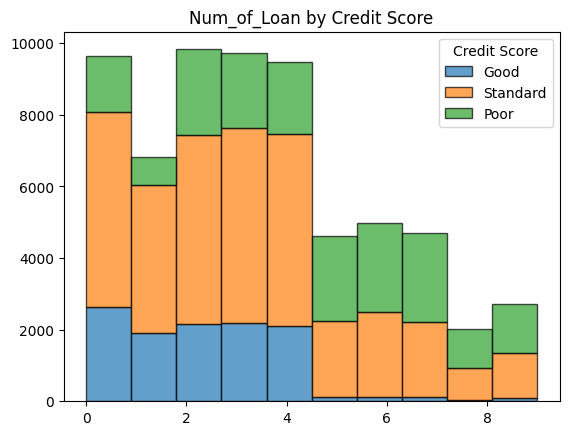

In [24]:
percentil = data['Num_of_Loan'].quantile(0.99)
data['Num_of_Loan'] = np.where(data['Num_of_Loan'] > percentil, percentil, data['Num_of_Loan'])
data["Num_of_Loan"] = np.where(data["Num_of_Loan"] < 0, 0, data["Num_of_Loan"])

create_histogram(data, 'Num_of_Loan', bins=10)

-0.2899330713672655


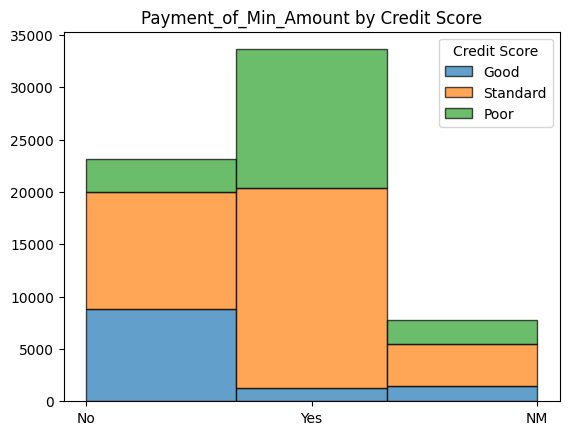

In [25]:
create_histogram(data, 'Payment_of_Min_Amount', bins=3)

0.10451479441932109


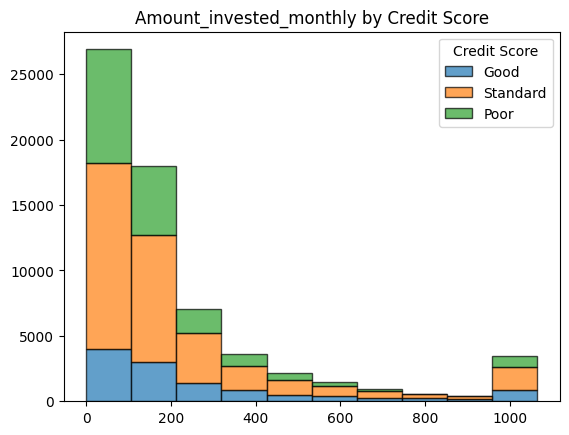

In [26]:
per = np.percentile(data['Amount_invested_monthly'],95)
data['Amount_invested_monthly'] = np.where(data['Amount_invested_monthly']>per,per,data['Amount_invested_monthly'])
create_histogram(data, 'Amount_invested_monthly', bins=10)

0.1643427126840766


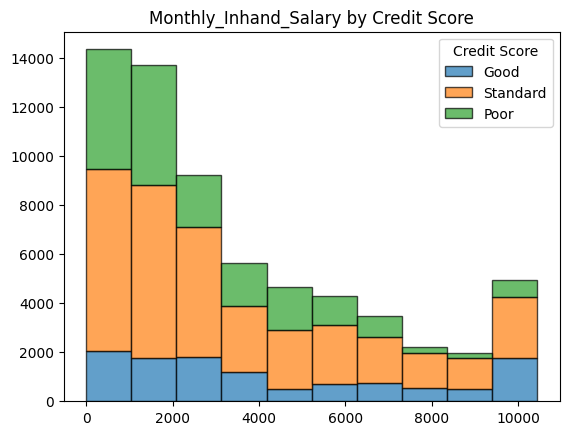

In [27]:
per = np.percentile(data['Monthly_Inhand_Salary'],95)
data['Monthly_Inhand_Salary'] = np.where(data['Monthly_Inhand_Salary']>per,per,data['Monthly_Inhand_Salary'])
create_histogram(data, 'Monthly_Inhand_Salary', bins=10)

Accuracy en datos de entrenamiento: 0.39


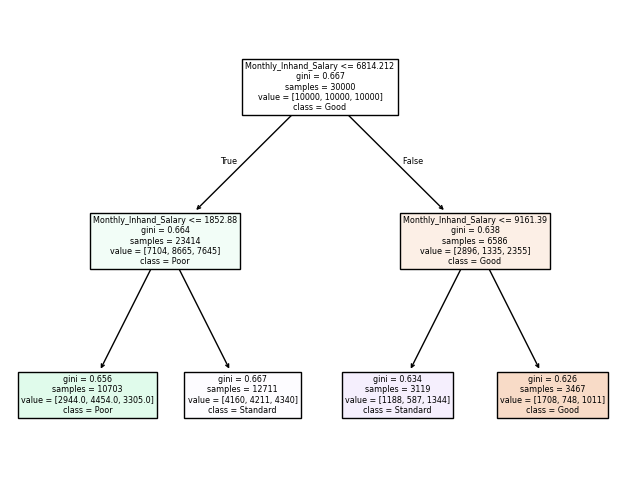

In [28]:
create_decission_tree(data, 'Monthly_Inhand_Salary', depth = 2)

-0.3840624390550362


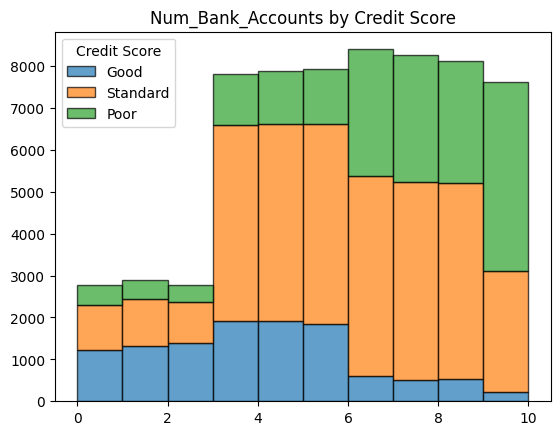

In [29]:
create_histogram(data, 'Num_Bank_Accounts', bins=10)

Accuracy en datos de entrenamiento: 0.47


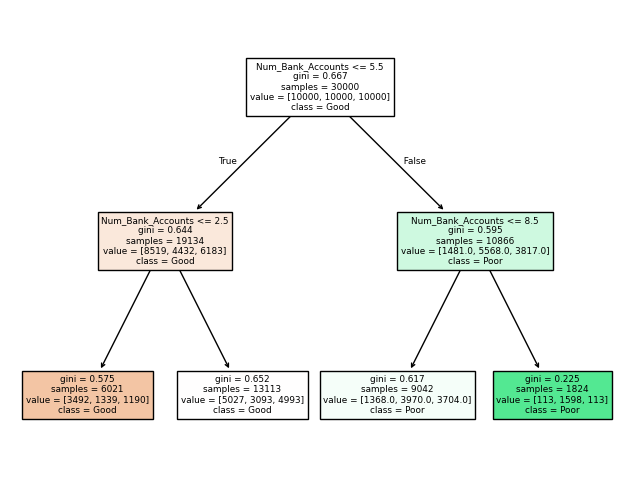

In [31]:
create_decission_tree(data, "Num_Bank_Accounts")

In [32]:
create_logistic_regression(data, "Num_Bank_Accounts")

Accuracy en datos de entrenamiento: 0.47
[[-0.20695048]
 [ 0.17408064]
 [ 0.03286984]]
[ 0.90300953 -0.82140845 -0.08160108]


-0.012860081154746716


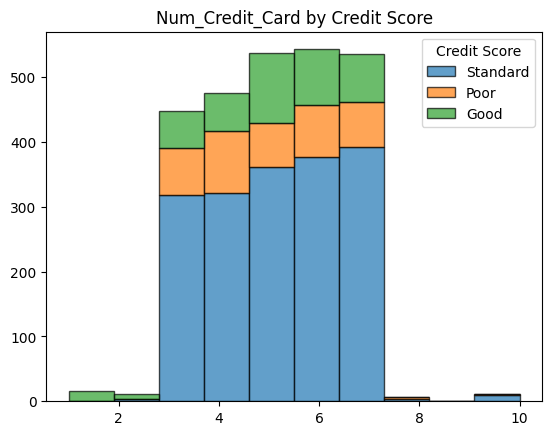

In [37]:
condicional = (data["Num_of_Loan"]==0) & (data['Delay_from_due_date']>15)
create_histogram(data[condicional], "Num_Credit_Card", bins = 10)

-0.2711508730339706


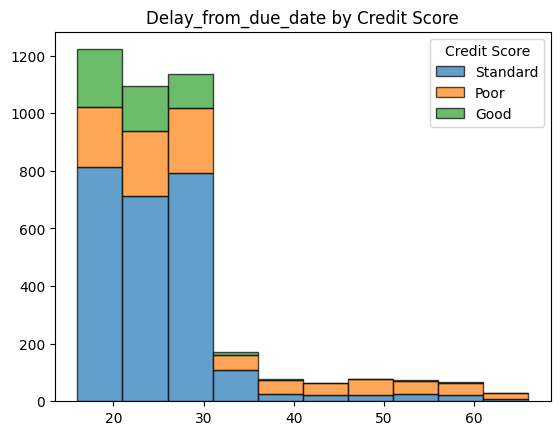

In [43]:
condicional = (data['Num_of_Loan']==0) & (data['Delay_from_due_date']>15)
create_histogram(data[condicional], "Delay_from_due_date", bins = 10)

0.18437091387013535


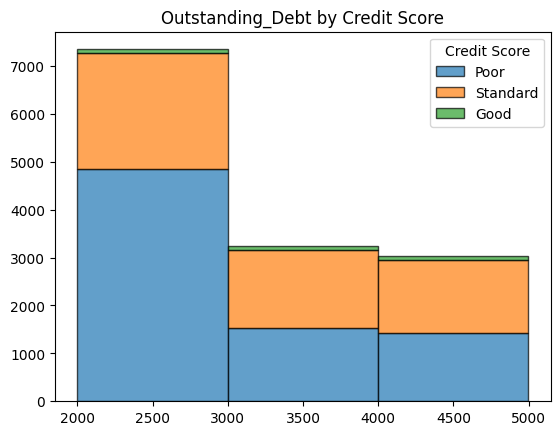

In [ ]:
# Ajuste de Outsanding_Debt y el pago mínimo
condicional = (data['Outstanding_Debt']>=2000) & (data['Payment_of_Min_Amount']==2)
create_histogram(data[condicional], "Outstanding_Debt", bins = 3)